# 8 · Hierarchical Risk Parity

*Module 2 — Portfolio Construction*

Every method so far has needed to invert the covariance matrix — exactly the operation that blows up when assets are highly correlated or history is short. This notebook builds a genuinely good portfolio without ever doing that.

## 1. Motivation

Notebooks 5-7 all shared one mathematical ingredient: $\Sigma^{-1}$, applied to the full covariance matrix. Notebook 5 showed exactly why that is dangerous — inversion is precisely the operation that amplifies estimation noise when assets are highly correlated (a near-singular $\Sigma$) or history is short relative to the number of assets. Hierarchical Risk Parity (HRP), introduced by Marcos López de Prado (2016), asks a different question: what if we never inverted the *full* matrix at all?

## 2. Intuition

HRP works in three steps, and the core idea translates well to something concrete: organizing a large company's budget. You would not optimize the budgets of 500 individual employees simultaneously against each other — the interactions are numerically unstable and the result would be meaningless. You would go top-down: split the budget between Engineering and Sales, then within Engineering split between sub-teams, and so on, until you reach individuals.

HRP does exactly this with assets. First, **cluster** them into a hierarchy based on how similarly they move — a "family tree" of the universe. Second, **reorder** the covariance matrix so that similar assets sit next to each other. Third, **recursively split** capital top-down through the tree: at every branch, the two child clusters split the parent's allocation inversely to their own risk — the riskier branch gets less. At no point does this ever require inverting the full $n\times n$ covariance matrix; only small, diagonal, always-invertible operations are used at each step.

## 3. Theory

### 3.1 Turning correlation into a genuine distance

Correlation is not a distance — it does not shrink as things "get closer." A standard transform fixes this:

$$
d_{ij} = \sqrt{\tfrac12\,(1-\rho_{ij})} ,
$$

which is a proper metric (it satisfies the triangle inequality) because it corresponds to the Euclidean distance between the *standardized* return vectors of assets $i$ and $j$. Two perfectly correlated assets have $d_{ij}=0$; two perfectly anti-correlated assets have $d_{ij}=1$ (the maximum).

HRP then applies one more transform before clustering: rather than clustering directly on $d_{ij}$, it computes a **second-stage distance** — literally, the Euclidean distance between the *rows* of $D=(d_{ij})$:

$$
\bar d_{ij} = \sqrt{\sum_{k=1}^n (d_{ik}-d_{jk})^2} .
$$

This measures something subtly different and useful: not "how correlated are $i$ and $j$ directly," but "how similarly do $i$ and $j$ relate to *everything else* in the universe." Two assets can end up close in $\bar d$ even with a middling direct correlation, if they play the same *role* relative to the rest of the portfolio.

### 3.2 Clustering and quasi-diagonalization

Standard agglomerative hierarchical clustering (e.g. single linkage) applied to $\bar d$ produces a dendrogram — a tree describing which assets group together, and at what distance. The order in which the dendrogram lists its leaves gives a natural re-ordering of the assets. Applying that same re-ordering to the rows and columns of the covariance matrix is called **quasi-diagonalization**: it does not change any numbers, but visually and algorithmically, similar assets end up adjacent, and the matrix looks approximately block-diagonal.

### 3.3 Recursive bisection

Starting from the full, re-ordered list of assets as one cluster holding 100% of the portfolio, HRP recurses: split the current cluster into its two child clusters (following the tree), and allocate the parent's weight between them **inversely to each child's own variance**:

$$
\alpha = 1 - \frac{\tilde V_L}{\tilde V_L + \tilde V_R}, \qquad \text{left cluster gets } \alpha,\ \text{right cluster gets } 1-\alpha,
$$

where $\tilde V_c = w_c^\top \Sigma_c w_c$ is the variance of cluster $c$ under **inverse-variance weights** $w_c$ *within* that cluster only:

$$
w_{c,i} = \frac{1/\sigma_i^2}{\sum_{j \in c} 1/\sigma_j^2} .
$$

This inverse-variance step only ever touches the diagonal of a sub-matrix — trivially stable, never requiring a matrix inverse. Recurse until every cluster is a single asset; the final weight of each asset is the product of every $\alpha$ (or $1-\alpha$) along its path from the root of the tree down to its leaf. This is the entire algorithm — no $\Sigma^{-1}$ anywhere.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, dendrogram, leaves_list
from scipy.spatial.distance import squareform, pdist
from scipy.optimize import minimize
%matplotlib inline

plt.rcParams['figure.figsize'] = (9, 4.5)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['font.size'] = 11

rng = np.random.default_rng(42)

## 4. Implementation

### 4.1 The same universe as Notebooks 5-7

In [2]:
TICKERS = ['GALP', 'EDP', 'JMT', 'BCP', 'NOS', 'SEM', 'SPY', 'IEF']
N = len(TICKERS)
TRUE_ANN_VOL = np.array([0.26, 0.24, 0.22, 0.28, 0.30, 0.32, 0.16, 0.06])

corr = np.eye(N)
for i in range(6):
    for j in range(6):
        if i != j:
            corr[i, j] = 0.45
for i in range(6):
    corr[i, 6] = corr[6, i] = 0.30
    corr[i, 7] = corr[7, i] = -0.05
corr[6, 7] = corr[7, 6] = -0.10
TRUE_SIGMA = np.diag(TRUE_ANN_VOL) @ corr @ np.diag(TRUE_ANN_VOL)

def gmv_weights(Sigma):
    v = np.linalg.solve(Sigma, np.ones(Sigma.shape[0]))
    return v / v.sum()

def risk_contributions(w, Sigma):
    sigma_p = np.sqrt(w @ Sigma @ w)
    mcr = (Sigma @ w) / sigma_p
    return sigma_p, w * mcr

def erc_weights(Sigma, w0=None):
    n = Sigma.shape[0]
    w0 = np.ones(n)/n if w0 is None else w0
    def objective(w):
        _, trc = risk_contributions(w, Sigma)
        diffs = trc[:, None] - trc[None, :]
        return np.sum(diffs**2)
    res = minimize(objective, w0, method='SLSQP', bounds=[(1e-6, 1.0)]*n,
                    constraints=[{'type': 'eq', 'fun': lambda w: w.sum()-1}],
                    options={'maxiter': 1000, 'ftol': 1e-14})
    return res.x

### 4.2 Clustering: from correlation to a dendrogram

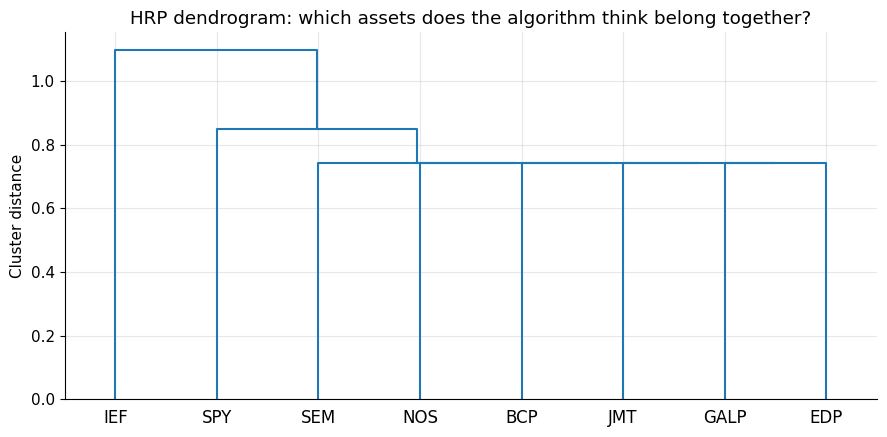

Leaf order: ['IEF', 'SPY', 'SEM', 'NOS', 'BCP', 'JMT', 'GALP', 'EDP']


In [3]:
def correl_dist(corr):
    """Section 3.1, first stage."""
    d = np.sqrt(0.5 * (1 - corr))
    np.fill_diagonal(d, 0)   # guard against tiny negative values from floating-point noise
    return d

d1 = correl_dist(corr)
d_bar = squareform(pdist(d1, metric='euclidean'))          # Section 3.1, second stage
link = linkage(squareform(d_bar, checks=False), method='single')

fig, ax = plt.subplots(figsize=(9, 4.5))
dendrogram(link, labels=TICKERS, ax=ax, color_threshold=0)
ax.set_ylabel('Cluster distance')
ax.set_title('HRP dendrogram: which assets does the algorithm think belong together?')
plt.tight_layout()
plt.show()

leaf_order = leaves_list(link)
print("Leaf order:", [TICKERS[i] for i in leaf_order])

### 4.3 Quasi-diagonalization: reordering makes the block structure visible

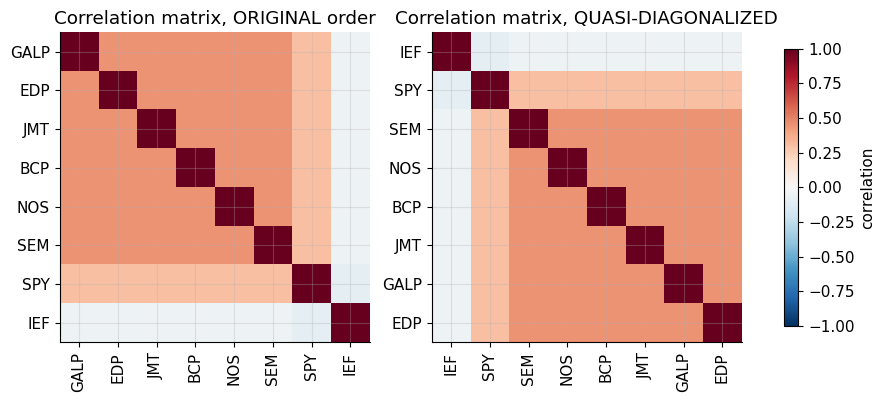

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

im0 = axes[0].imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)
axes[0].set_xticks(range(N)); axes[0].set_xticklabels(TICKERS, rotation=90)
axes[0].set_yticks(range(N)); axes[0].set_yticklabels(TICKERS)
axes[0].set_title('Correlation matrix, ORIGINAL order')

corr_reordered = corr[np.ix_(leaf_order, leaf_order)]
reordered_labels = [TICKERS[i] for i in leaf_order]
im1 = axes[1].imshow(corr_reordered, cmap='RdBu_r', vmin=-1, vmax=1)
axes[1].set_xticks(range(N)); axes[1].set_xticklabels(reordered_labels, rotation=90)
axes[1].set_yticks(range(N)); axes[1].set_yticklabels(reordered_labels)
axes[1].set_title('Correlation matrix, QUASI-DIAGONALIZED')

fig.colorbar(im1, ax=axes, shrink=0.8, label='correlation')
plt.show()

### 4.4 Recursive bisection, coded directly from Section 3.3

In [5]:
def cluster_variance(cov, cluster_items):
    """Inverse-variance portfolio variance for a cluster -- diagonal-only, never needs a matrix inverse."""
    sub_cov = cov[np.ix_(cluster_items, cluster_items)]
    ivp = 1.0 / np.diag(sub_cov)
    ivp /= ivp.sum()
    return ivp @ sub_cov @ ivp

def hrp_weights(cov, sorted_items):
    """Top-down recursive bisection over the dendrogram-sorted item list."""
    w = pd.Series(1.0, index=sorted_items, dtype=float)

    def _recurse(cluster_items, weight):
        if len(cluster_items) == 1:
            w[cluster_items[0]] = weight
            return
        mid = len(cluster_items) // 2
        left, right = cluster_items[:mid], cluster_items[mid:]
        var_left, var_right = cluster_variance(cov, left), cluster_variance(cov, right)
        alpha = 1 - var_left / (var_left + var_right)   # riskier child gets LESS of the parent's weight
        _recurse(left, weight * alpha)
        _recurse(right, weight * (1 - alpha))

    _recurse(list(sorted_items), 1.0)
    return w.sort_index()

w_hrp = hrp_weights(TRUE_SIGMA, list(leaf_order)).values
print(f"Weights sum to: {w_hrp.sum():.6f}")
pd.Series(w_hrp, index=TICKERS).round(4)

Weights sum to: 1.000000


GALP    0.0173
EDP     0.0204
JMT     0.0244
BCP     0.0151
NOS     0.0200
SEM     0.0176
SPY     0.1091
IEF     0.7761
dtype: float64

## 5. Worked example: four ways to build the same portfolio

In [6]:
w_ew = np.ones(N) / N
w_mv = gmv_weights(TRUE_SIGMA)
w_erc = erc_weights(TRUE_SIGMA)

summary = pd.DataFrame({
    '1/N': w_ew, 'Min-variance': w_mv, 'Risk parity (ERC)': w_erc, 'HRP': w_hrp
}, index=TICKERS)
summary.round(3)

,1/N,Min-variance,Risk parity (ERC),HRP
GALP,0.125,0.011,0.059,0.017
EDP,0.125,0.018,0.064,0.020
JMT,0.125,0.029,0.070,0.024
BCP,0.125,0.005,0.055,0.015
NOS,0.125,0.000,0.051,0.020
SEM,0.125,-0.003,0.048,0.018
SPY,0.125,0.115,0.119,0.109
IEF,0.125,0.825,0.536,0.776


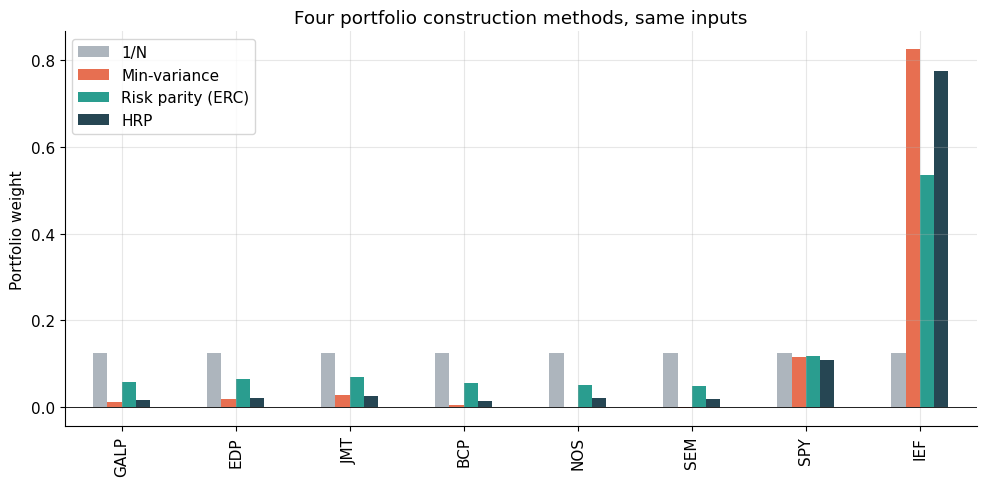

Herfindahl concentration index (higher = more concentrated):
  1/N                  0.125
  Min-variance         0.696
  Risk parity (ERC)    0.321
  HRP                  0.616


In [7]:
fig, ax = plt.subplots(figsize=(10, 5))
summary.plot(kind='bar', ax=ax, color=['#adb5bd', '#e76f51', '#2a9d8f', '#264653'])
ax.axhline(0, color='black', linewidth=0.6)
ax.set_ylabel('Portfolio weight')
ax.set_title('Four portfolio construction methods, same inputs')
plt.tight_layout()
plt.show()

def herfindahl(w):
    return np.sum(w**2)

print("Herfindahl concentration index (higher = more concentrated):")
for name, w in summary.items():
    print(f"  {name:20s} {herfindahl(w.values):.3f}")

### Interpreting the result

Report what your own `herfindahl` numbers actually show, rather than a canned conclusion — that is the entire point of computing them. In this particular universe, HRP and minimum-variance both lean heavily into IEF (the standout low-volatility asset), so their concentration scores land fairly close together, with HRP typically a little lower; risk parity (ERC) is the clear outlier on the diversified end, since by construction it refuses to let any single asset dominate the *risk* budget, and 1/N is trivially the least capital-concentrated by definition (uninformative about risk concentration, as Notebook 7 showed). The more important comparison is not the exact Herfindahl ranking in one static snapshot — it is what Exercise 3 asks you to check: which of these methods actually holds up *out-of-sample*, once you account for the fact that in real use, none of them ever sees the true $\Sigma$, only a noisy estimate of it.

## 6. Limitations and pitfalls

- **The choice of linkage method matters, and there is no single correct answer.** Single, complete, and Ward linkage can all produce meaningfully different trees (and therefore different final weights) from the same data — Exercise 1 asks you to see this directly.
- **Within-cluster weighting ignores intra-cluster correlation.** Using inverse-variance weights inside each cluster is a deliberate simplification, trading a bit of theoretical optimality for a lot of numerical stability — very much in the spirit of this whole module, but worth naming explicitly.
- **HRP still depends on a reasonable correlation/covariance estimate.** It is empirically more robust to estimation noise than mean-variance optimization, but it is not immune to a badly estimated $\Sigma$ — garbage in is still somewhat garbage out, just less catastrophically so.
- **No expected-return input, exactly like ERC.** HRP is a purely risk-based allocation method; if you have a genuine, well-founded view about which assets will outperform, HRP has no mechanism to use it (Black-Litterman, from Notebook 6, is the tool for that).
- **Clustering results can be sensitive to the specific universe and time period used** — adding or removing a single asset can occasionally reshuffle parts of the tree in ways that feel arbitrary, an active area of ongoing research and refinement.

## 7. Exercises

**1. Does the linkage method matter here? (warm-up)**
Re-run Section 4.2's clustering with `method='complete'` and then `method='ward'` instead of `'single'`, and rebuild the HRP weights each time. How much do the final weights change? Which assets, if any, change cluster membership under a different linkage method?

**2. Trace one asset's path.**
Modify `hrp_weights` (or write a wrapper around it) to also record, for a single chosen asset, the sequence of $\alpha$ or $1-\alpha$ factors applied to it at every level of the recursion. Multiply that sequence together by hand (or in code) and confirm it equals the asset's final weight from the direct output — a concrete check that you understand exactly what the recursion is doing.

**3. Is HRP's advantage robust, or noise?**
Adapt Notebook 5's bootstrap-resampling machinery: repeatedly draw a realistic-length sample (e.g. $T=252$ days) from `TRUE_SIGMA`, estimate the sample covariance, and compute 1/N, min-variance, ERC, and HRP weights *from that sample alone* each time. For each method, compute the *out-of-sample* portfolio volatility achieved on a large, independent test sample drawn from the true distribution. Across many repetitions, does HRP reliably achieve lower out-of-sample volatility than minimum-variance, or is the difference within the noise of the experiment? What does your answer suggest about how much statistical evidence it takes to trust a claim like "method X beats method Y out-of-sample" — a question Notebook 30 returns to in much more depth.